# Unsupervised Learning Fundamentals

A complete foundation for understanding **Unsupervised Machine Learning** before studying K-Means, Hierarchical Clustering, DBSCAN, Gaussian Mixture Models, PCA, and other unsupervised methods.

## Learning path

**Supervised Learning → Unsupervised Learning → Clustering → Similarity & Distance → Evaluation Without Labels → Main Unsupervised Algorithms → K-Means Preview**

## Learning objectives

By the end of this notebook, you will understand:

- What Unsupervised Learning is and how it differs from Supervised Learning.
- Why the absence of labels changes the learning problem.
- Clustering, dimensionality reduction, anomaly detection, and density estimation.
- Similarity and distance metrics.
- Euclidean, Manhattan, and Cosine distance/similarity.
- Why feature scaling matters.
- Why ordinary classification accuracy is usually unavailable.
- Internal versus external clustering evaluation.
- Silhouette Score and its limitations.
- The main families of clustering algorithms.
- The conceptual workflow of K-Means.

> **Important:** This notebook builds the conceptual foundation. K-Means will be studied in depth in the next notebook.

# 1. What is Unsupervised Learning?

In **Supervised Learning**, training data contains inputs and known targets:

$$
X \rightarrow y
$$

where \(X\) represents features and \(y\) represents a target label or continuous value.

Examples:

- Predict whether a tumor is malignant or benign.
- Predict house prices.
- Predict survival time.

In **Unsupervised Learning**, training data contains the input representation:

$$
X
$$

but the target \(y\) is not supplied to the algorithm.

The model instead searches for structure, regularities, relationships, or unusual observations in the data.

> **Supervised Learning learns from known answers; Unsupervised Learning searches for structure when the answers are not provided.**

# 2. Supervised vs Unsupervised Learning

| Property | Supervised Learning | Unsupervised Learning |
|---|---|---|
| Input | \(X\) | \(X\) |
| Target | Available | Usually unavailable |
| Main goal | Predict a target | Discover structure |
| Typical tasks | Classification, Regression | Clustering, Dimensionality Reduction |
| Common metrics | Accuracy, F1, RMSE, ROC-AUC | Silhouette, reconstruction error, density criteria |
| Training signal | Labels/targets | Structure in the input data |

The deeper difference is not merely "labels versus no labels."

It is:

> **What information defines the learning objective?**

In [1]:
# Import the numerical and visualization libraries used in this notebook.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import datasets for demonstrations.
from sklearn.datasets import make_blobs, load_iris

# Import preprocessing tools to demonstrate feature scaling.
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Import distance and similarity functions.
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_similarity

# Import an internal clustering evaluation metric.
from sklearn.metrics import silhouette_score

# Fix the random seed so demonstrations are reproducible.
RANDOM_STATE = 42

# Apply a consistent visual style.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


# 3. Why "unsupervised" does not mean "no information"

The absence of labels does **not** mean that a dataset contains no structure.

It can still contain:

- Correlations.
- Groups.
- Density variations.
- Repeated patterns.
- Low-dimensional structure.
- Outliers.
- Latent representations.

The algorithm simply is not told which interpretation is correct in advance.

This creates an important issue:

> The same dataset can support multiple mathematically reasonable interpretations depending on the features, distance metric, preprocessing, and algorithm.

# 4. Major Types of Unsupervised Learning

## 4.1 Clustering

Discover groups of observations according to similarity.

Examples:

- K-Means
- Hierarchical Clustering
- DBSCAN
- Gaussian Mixture Models

## 4.2 Dimensionality Reduction

Represent high-dimensional data using fewer dimensions while preserving important structure.

Examples:

- PCA
- t-SNE
- UMAP

## 4.3 Anomaly Detection

Identify observations that differ substantially from the majority.

Examples:

- Isolation Forest
- Local Outlier Factor
- One-Class SVM

## 4.4 Density Estimation

Estimate the distribution or density of observations in feature space.

Examples:

- Kernel Density Estimation
- Gaussian Mixture Models

These categories can overlap. For example, a density model can support both clustering and anomaly detection.

# 5. Clustering

Given observations

$$
X=\{x_1,x_2,\ldots,x_n\}
$$

clustering attempts to discover groups such that observations within a group are relatively similar and observations between groups are relatively different.

The crucial question is:

> **What does "similar" mean?**

There is no meaningful clustering problem without some definition of similarity, distance, density, or another structural criterion.

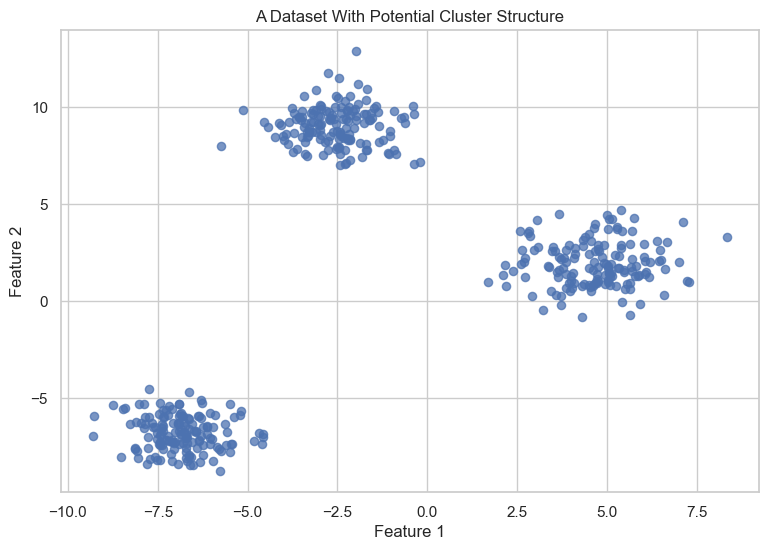

In [2]:
# Generate a two-dimensional dataset with several visible groups.
# The hidden labels are NOT used for the unsupervised demonstration.
X_blobs, hidden_labels = make_blobs(
    n_samples=450,
    centers=3,
    cluster_std=[1.0, 1.2, 0.9],
    random_state=RANDOM_STATE,
)

# Plot the observations without using the hidden labels.
plt.figure(figsize=(9, 6))
plt.scatter(
    X_blobs[:, 0],
    X_blobs[:, 1],
    s=35,
    alpha=0.75,
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("A Dataset With Potential Cluster Structure")
plt.show()

The previous plot visually suggests groups even though no labels were supplied to an unsupervised algorithm.

The variable `hidden_labels` exists only because `make_blobs` generated synthetic ground truth.

In a genuinely unsupervised real-world problem, such labels may not exist.

This distinction becomes important when we discuss evaluation.

# 6. Similarity and Distance

For two observations \(x_i\) and \(x_j\), an algorithm often needs a numerical measure of how close they are.

A **distance** generally assigns smaller values to more similar observations.

A **similarity** generally assigns larger values to more similar observations.

The choice of metric can change the geometry of the problem and therefore change the learned structure.

# 7. Euclidean Distance

The Euclidean distance is

$$
d(x,y)=
\sqrt{\sum_{j=1}^{p}(x_j-y_j)^2}
$$

For two dimensions:

$$
d(x,y)=
\sqrt{(x_1-y_1)^2+(x_2-y_2)^2}
$$
It is ordinary straight-line distance.

It is common in methods such as K-Means, but it is sensitive to feature scale.

Euclidean distance: 5.0


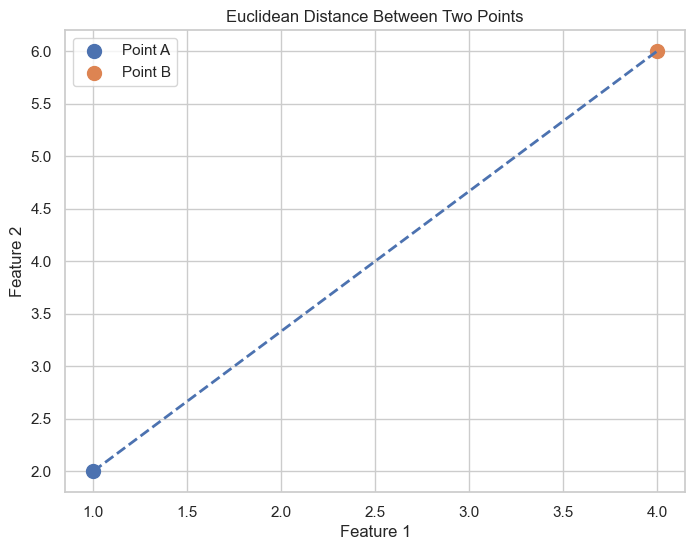

In [3]:
# Define two two-dimensional points.
point_a = np.array([[1.0, 2.0]])
point_b = np.array([[4.0, 6.0]])

# Calculate Euclidean distance using scikit-learn.
euclidean_distance = pairwise_distances(
    point_a,
    point_b,
    metric="euclidean",
)[0, 0]

print("Euclidean distance:", euclidean_distance)

# Visualize the two points and their straight-line distance.
plt.figure(figsize=(8, 6))
plt.scatter(point_a[:, 0], point_a[:, 1], s=100, label="Point A")
plt.scatter(point_b[:, 0], point_b[:, 1], s=100, label="Point B")
plt.plot(
    [point_a[0, 0], point_b[0, 0]],
    [point_a[0, 1], point_b[0, 1]],
    linestyle="--",
    linewidth=2,
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Euclidean Distance Between Two Points")
plt.legend()
plt.show()

# 8. Manhattan Distance

Manhattan distance is

$$
d(x,y)=\sum_{j=1}^{p}|x_j-y_j|
$$

It sums absolute coordinate differences rather than measuring the straight-line path.

It can be useful when absolute coordinate differences are more meaningful than Euclidean geometry.

In [4]:
# Calculate Manhattan distance between the same two points.
manhattan_distance = pairwise_distances(
    point_a,
    point_b,
    metric="manhattan",
)[0, 0]

print("Manhattan distance:", manhattan_distance)

Manhattan distance: 7.0


# 9. Cosine Similarity

Cosine similarity compares the direction of two vectors:

$$
\text{cosine}(x,y)=
\frac{x\cdot y}{\|x\|\|y\|}
$$

It is high when vectors point in similar directions, even when their magnitudes differ.

It is often useful for high-dimensional representations such as text/document vectors.

The appropriate similarity measure depends on the domain and the meaning of "similarity."

Cosine similarity: 1.0


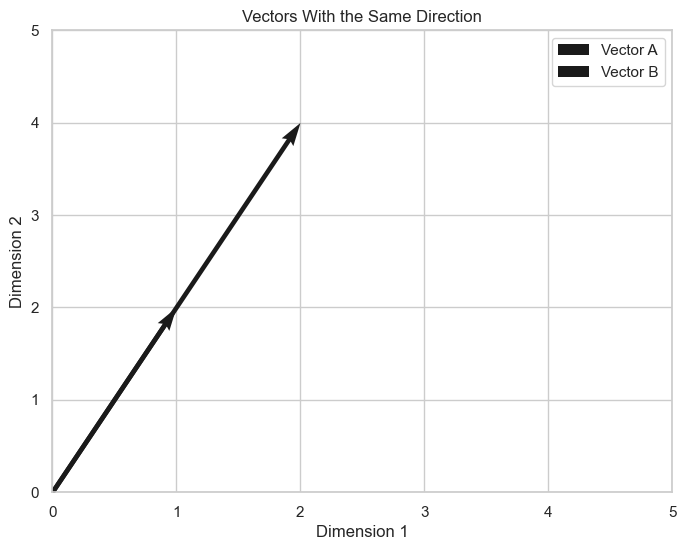

In [5]:
# Create two vectors with the same direction but different magnitudes.
vector_a = np.array([[1.0, 2.0, 3.0]])
vector_b = np.array([[2.0, 4.0, 6.0]])

# Calculate cosine similarity.
cosine_sim = cosine_similarity(vector_a, vector_b)[0, 0]

print("Cosine similarity:", cosine_sim)

# Visualize the first two dimensions to build geometric intuition.
plt.figure(figsize=(8, 6))
plt.quiver(
    0, 0,
    vector_a[0, 0],
    vector_a[0, 1],
    angles="xy",
    scale_units="xy",
    scale=1,
    label="Vector A",
)
plt.quiver(
    0, 0,
    vector_b[0, 0],
    vector_b[0, 1],
    angles="xy",
    scale_units="xy",
    scale=1,
    label="Vector B",
)
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("Vectors With the Same Direction")
plt.legend()
plt.show()

# 10. Why Feature Scaling Matters

Consider two features:

- Age: approximately 20–80.
- A measurement: approximately 0–1.

With Euclidean distance, the larger numerical scale can dominate the distance even if it is not scientifically more important.

Common transformations include:

### Standardization

$$
z=\frac{x-\mu}{\sigma}
$$

### Min-Max Scaling

$$
x'=\frac{x-x_{\min}}{x_{\max}-x_{\min}}
$$

Scaling does not create information. It changes the coordinate system so numerical scales become more comparable.

Distance-based methods such as K-Means and KNN are strongly affected by scaling, whereas ordinary Decision Trees are generally not.

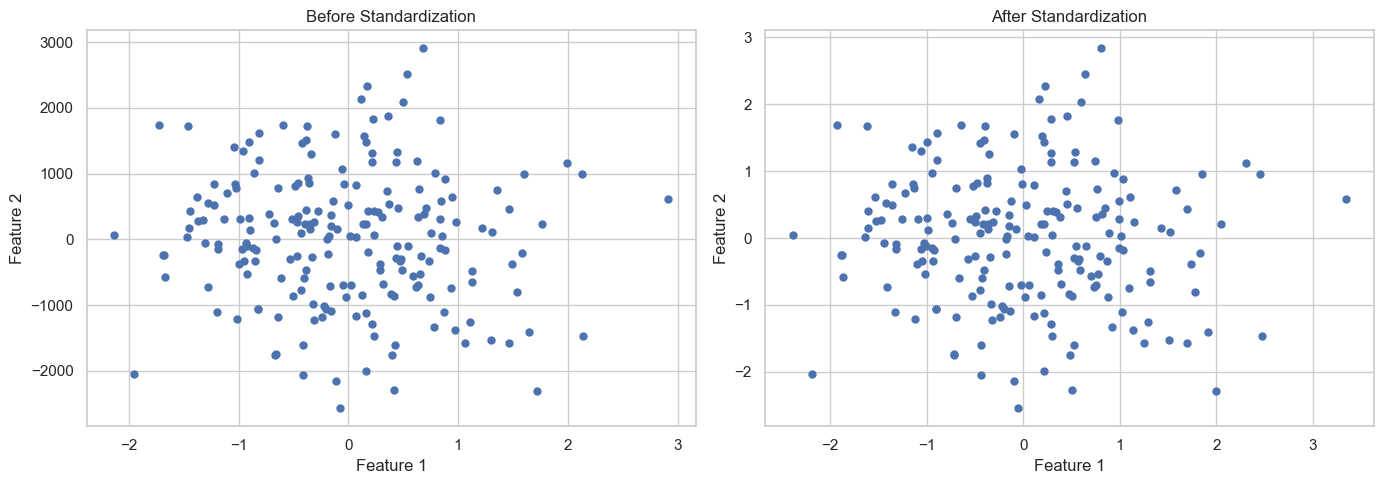

In [6]:
# Create two synthetic features with very different numerical scales.
rng = np.random.default_rng(RANDOM_STATE)

feature_small = rng.normal(0, 1, 200)
feature_large = rng.normal(0, 1000, 200)

# Combine the two features into one matrix.
X_scale = np.column_stack([feature_small, feature_large])

# Standardize both features.
X_standardized = StandardScaler().fit_transform(X_scale)

# Plot the original and standardized representations side by side.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_scale[:, 0], X_scale[:, 1], s=25)
axes[0].set_title("Before Standardization")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

axes[1].scatter(X_standardized[:, 0], X_standardized[:, 1], s=25)
axes[1].set_title("After Standardization")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

# 11. Why Clustering Is Not Classification

Classification asks:

> "Which known class does this observation belong to?"

Clustering asks:

> "Is there a useful grouping structure in these observations?"

In classification, class meanings are supplied externally.

In clustering, group assignments are created according to the algorithm's objective.

Therefore:

```text
Cluster 0
Cluster 1
Cluster 2
```

do not automatically mean:

```text
Healthy
Mild disease
Severe disease
```

A scientific interpretation requires independent evidence.

# 12. Why Accuracy Is Usually Unavailable

In supervised classification, we can compare true labels and predictions:

\[
y_{true} \quad \text{vs} \quad y_{pred}
\]

and calculate Accuracy, Precision, Recall, F1, ROC-AUC, and similar metrics.

In a genuinely unsupervised problem, the true labels may not exist.

Instead, we can evaluate properties such as:

- Compactness.
- Separation.
- Density.
- Stability.
- Reconstruction quality.
- Agreement with independent domain information.

Two broad categories are useful:

### Internal evaluation

Uses the data and the discovered structure itself.

### External evaluation

Uses an independently available reference label or ground truth.

External labels may be used to evaluate an unsupervised method, but they should not secretly become the training signal if the task is intended to remain unsupervised.

# 13. Silhouette Score

For a sample \(i\):

$$
s(i)=\frac{b(i)-a(i)}{\max(a(i),b(i))}
$$

where:

- \(a(i)\) is the average distance from the sample to its own cluster.
- \(b(i)\) is the lowest average distance from the sample to another cluster.

Interpretation:

- Near **1** → strong separation.
- Near **0** → overlapping clusters.
- Negative → the sample may fit another cluster better.

The overall silhouette score is the mean over observations.

> A high silhouette score indicates geometric separation. It does **not** prove that the discovered groups are biologically or scientifically meaningful.

Silhouette Score: 0.8630646944727309


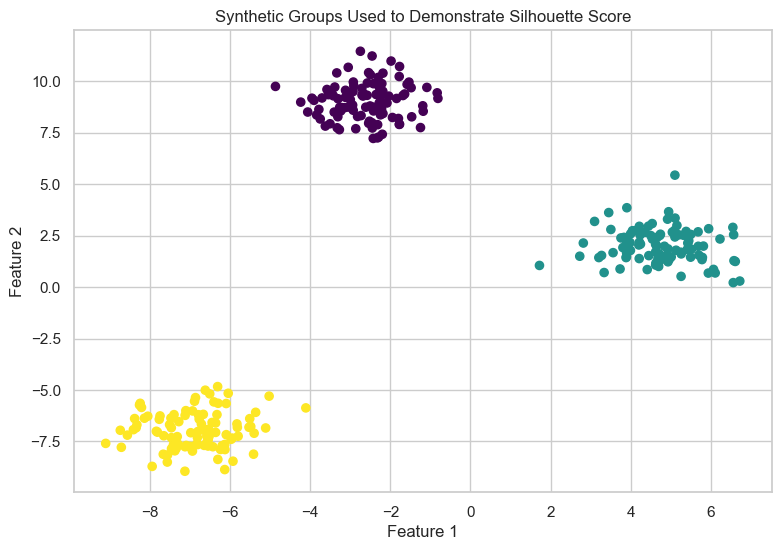

In [7]:
# Generate synthetic data and use its known groups only to demonstrate silhouette calculation.
X_silhouette, reference_labels = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.9,
    random_state=RANDOM_STATE,
)

# Calculate the silhouette score for the reference partition.
score = silhouette_score(X_silhouette, reference_labels)

print("Silhouette Score:", score)

# Visualize the reference partition for intuition.
plt.figure(figsize=(9, 6))
plt.scatter(
    X_silhouette[:, 0],
    X_silhouette[:, 1],
    c=reference_labels,
    s=35,
    cmap="viridis",
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Groups Used to Demonstrate Silhouette Score")
plt.show()

# 14. What Makes a Good Cluster?

Depending on the algorithm and application, useful groups may exhibit:

### Compactness
Members of the same group are close.

### Separation
Different groups are relatively far apart.

### Density
A cluster occupies a relatively dense region.

### Stability
The grouping remains reasonably consistent under small changes.

### Interpretability
The grouping has a defensible explanation in the application domain.

The last property is particularly important in scientific research.

A mathematically strong cluster can still be scientifically meaningless.

# 15. Main Clustering Algorithms

## K-Means

Centroid-based partitioning.

**Strength:** Simple, fast, strong baseline for compact clusters.

**Limitation:** Sensitive to scale, initialization, outliers, and cluster geometry; requires choosing \(K\).

## Hierarchical Clustering

Builds nested groups.

**Strength:** Reveals multi-level relationships.

**Limitation:** Can become expensive for large datasets and depends on linkage choices.

## DBSCAN

Finds dense regions and identifies noise.

**Strength:** Can discover irregularly shaped clusters and explicit noise.

**Limitation:** Sensitive to density parameters and struggles when cluster densities differ substantially.

## Gaussian Mixture Models

Models data as a mixture of probability distributions.

**Strength:** Provides soft/probabilistic membership.

**Limitation:** Depends on distributional assumptions and model specification.

In [8]:
# Summarize the main clustering algorithms in a compact comparison table.
algorithm_table = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical Clustering",
        "DBSCAN",
        "Gaussian Mixture Model",
    ],
    "Core idea": [
        "Centroid-based partitioning",
        "Nested hierarchy",
        "Density-connected regions",
        "Probabilistic mixture model",
    ],
    "Typical strength": [
        "Simple and scalable baseline",
        "Multi-level structure",
        "Irregular shapes and noise",
        "Soft cluster membership",
    ],
    "Main limitation": [
        "Needs K and favors certain geometries",
        "Can be expensive for large datasets",
        "Density-parameter sensitivity",
        "Distributional assumptions",
    ],
})

display(algorithm_table)

,Algorithm,Core idea,Typical strength,Main limitation
0,K-Means,Centroid-based partitioning,Simple and scalable baseline,Needs K and favors certain geometries
1,Hierarchical Clustering,Nested hierarchy,Multi-level structure,Can be expensive for large datasets
2,DBSCAN,Density-connected regions,Irregular shapes and noise,Density-parameter sensitivity
3,Gaussian Mixture Model,Probabilistic mixture model,Soft cluster membership,Distributional assumptions


# 16. Dimensionality Reduction

Suppose:

$$
X \in \mathbb{R}^{n\times p}
$$

with thousands of features.

Dimensionality reduction constructs a lower-dimensional representation:

$$
Z \in \mathbb{R}^{n\times k}
$$

where $$(k \ll p).$$

Common methods:

- PCA.
- t-SNE.
- UMAP.

Uses include:

- Visualization.
- Compression.
- Noise reduction.
- Representation analysis.
- Preprocessing for other models.

A 2D visualization should not automatically be treated as a faithful representation of every high-dimensional relationship.

# 17. Anomaly Detection

Anomaly detection attempts to identify observations that differ substantially from the majority.

Examples:

- Unusual transactions.
- Abnormal sensor readings.
- Rare biological samples.
- Unusual imaging patterns.

The difficult question is:

> What does "normal" mean?

Common algorithms include:

- Isolation Forest.
- Local Outlier Factor.
- One-Class SVM.

Anomaly detection is related to clustering, but it is not the same task.

# 18. Density Estimation

Density estimation attempts to estimate:

$$
p(x)
$$

the probability density over feature space.

It can help answer:

- Where is the data concentrated?
- Which regions are sparse?
- Which observations have unusually low density?

Examples include:

- Kernel Density Estimation.
- Gaussian Mixture Models.

Density estimation can support both clustering and anomaly detection.

# 19. Preprocessing Before Unsupervised Learning

Before fitting an unsupervised model, inspect:

1. Missing values.
2. Feature scales.
3. Outliers.
4. Categorical variables.
5. Correlated features.
6. Duplicate observations.
7. Batch/site effects.
8. Potential leakage.
9. The appropriate distance or similarity metric.

This is particularly important because there may be no target variable to reveal that something is wrong.

For example, an irrelevant feature with a huge numerical scale can dominate a distance-based clustering result.

In [9]:
# Load a built-in dataset to inspect the dimensionality and feature ranges.
iris = load_iris()

# Convert the feature matrix into a DataFrame for convenient inspection.
iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names,
)

# Display dataset dimensions.
print("Number of samples:", iris_df.shape[0])
print("Number of features:", iris_df.shape[1])

# Summarize feature ranges and dispersion.
feature_summary = pd.DataFrame({
    "min": iris_df.min(),
    "max": iris_df.max(),
    "mean": iris_df.mean(),
    "std": iris_df.std(),
})

display(feature_summary)

Number of samples: 150
Number of features: 4


,min,max,mean,std
sepal length (cm),4.3,7.9,5.843333,0.828066
sepal width (cm),2.0,4.4,3.057333,0.435866
petal length (cm),1.0,6.9,3.758000,1.765298
petal width (cm),0.1,2.5,1.199333,0.762238


# 20. Unsupervised Learning Workflow

```text
Raw Data
   ↓
Data Audit
   ↓
Cleaning / Missing Values
   ↓
Feature Representation
   ↓
Scaling / Transformation
   ↓
Distance / Similarity Choice
   ↓
Unsupervised Algorithm
   ↓
Discovered Structure
   ↓
Internal Evaluation
   ↓
Stability Analysis
   ↓
Domain Interpretation
   ↓
External Validation (when available)
```

The absence of a target makes interpretation and validation especially important.

# 21. A Critical Scientific Point

Suppose an algorithm produces three clusters.

That does **not** prove that the population objectively contains three natural biological subtypes.

The result can depend on:

- Feature selection.
- Scaling.
- Distance metric.
- Number of clusters.
- Initialization.
- Algorithm assumptions.
- Noise.
- Batch effects.
- Sampling.
- Preprocessing.

A defensible scientific statement is closer to:

> "Under this representation, distance metric, algorithm, and parameterization, the data exhibits this clustering structure."

rather than:

> "The dataset objectively contains these biological groups."

# 22. K-Means: Conceptual Preview

The next notebook focuses entirely on **K-Means Clustering**.

The basic idea of K-Means is an iterative optimization process:

1. Choose \(K\) initial cluster centroids.
2. Assign each observation to the nearest centroid.
3. Recalculate each centroid as the mean of the observations assigned to it.
4. Repeat the assignment and update steps.
5. Stop when the centroids or cluster assignments no longer change significantly.

The objective of K-Means is to minimize the **Within-Cluster Sum of Squares (WCSS)**:

$$
J =
\sum_{k=1}^{K}
\sum_{x_i \in C_k}
\|x_i-\mu_k\|^2
$$

where:

- \(K\) is the number of clusters.
- \(C_k\) is the set of observations assigned to cluster \(k\).
- \(x_i\) is an observation belonging to cluster \(C_k\).
- \(\mu_k\) is the centroid (mean vector) of cluster \(k\).
- \(\|x_i-\mu_k\|^2\) is the squared Euclidean distance between an observation and its cluster centroid.

### What is K-Means trying to achieve?

K-Means tries to create clusters in which observations are **close to their own centroid**.

Therefore:

- Smaller within-cluster distances → smaller objective value.
- Larger within-cluster distances → larger objective value.

In other words:

> **K-Means searches for cluster assignments and centroids that minimize the total squared distance between observations and their assigned cluster centroids.**

The next notebook will derive this objective mathematically and implement the complete K-Means algorithm **from scratch using NumPy**, followed by a practical implementation using `scikit-learn`.

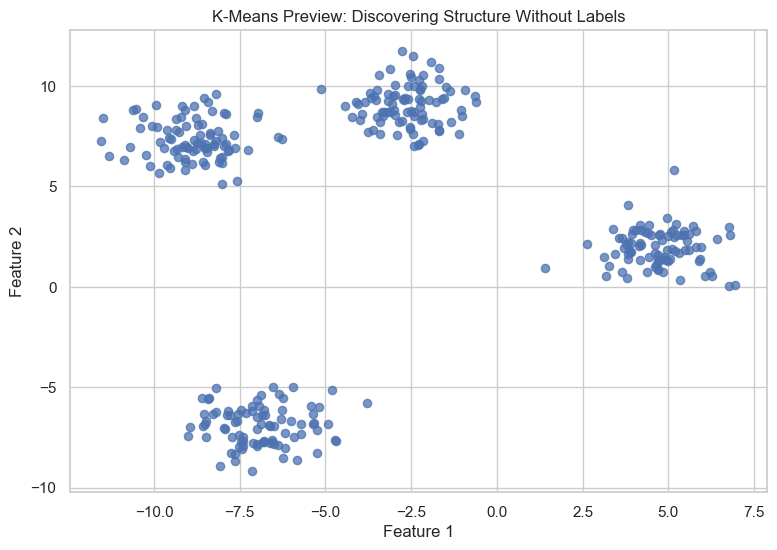

In [10]:
# Generate a simple dataset to preview the kind of structure K-Means can discover.
X_preview, _ = make_blobs(
    n_samples=350,
    centers=4,
    cluster_std=1.0,
    random_state=RANDOM_STATE,
)

# Display the observations without using the hidden labels.
plt.figure(figsize=(9, 6))
plt.scatter(
    X_preview[:, 0],
    X_preview[:, 1],
    s=35,
    alpha=0.75,
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Preview: Discovering Structure Without Labels")
plt.show()

# 23. What the K-Means Notebook Will Cover

The next notebook will be:

**`02_K-Means_Clustering_Complete_EN.ipynb`**

It will cover:

### Foundations
- Problem definition.
- Intuition.
- Centroids.
- Cluster assignment.

### Mathematics
- Within-cluster sum of squares.
- Objective function.
- Assignment step.
- Update step.
- Convergence.

### From Scratch
- NumPy implementation.
- Centroid movement visualization.
- Cluster assignment visualization.

### Scikit-learn
- `KMeans`.
- `k-means++`.
- `n_init`.
- `max_iter`.
- `tol`.

### Choosing K
- Elbow Method.
- Silhouette Score.
- Limitations of both methods.

### Failure Cases
- Poor initialization.
- Unequal cluster sizes.
- Non-spherical clusters.
- Outliers.
- Feature scaling.
- High-dimensional data.

### Applications
- Customer segmentation.
- Biological subtyping.
- Imaging-feature clustering.
- Exploratory data analysis.

# 24. Final Summary

The most important ideas are:

- **Unsupervised Learning searches for structure without a supplied target.**
- **Clustering depends on a definition of similarity or distance.**
- **Feature scaling can substantially change distance-based results.**
- **Classification accuracy is usually unavailable without independent labels.**
- **Internal metrics measure mathematical structure, not scientific truth.**
- **Clustering, dimensionality reduction, anomaly detection, and density estimation are different tasks.**
- **Unsupervised results require careful validation and interpretation.**
- **K-Means is a centroid-based clustering method and will be our first complete unsupervised algorithm.**

> **Core principle:** An unsupervised model discovers structure according to its mathematical assumptions and the representation we provide. It does not automatically discover the "true" structure of reality.

# References

1. Scikit-learn User Guide — Unsupervised Learning.
2. Scikit-learn User Guide — Clustering.
3. Scikit-learn User Guide — Preprocessing and Scaling.
4. James, Witten, Hastie, Tibshirani — *An Introduction to Statistical Learning*.
5. Hastie, Tibshirani, Friedman — *The Elements of Statistical Learning*.
6. Géron — *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*.

This notebook is an educational foundation and should be adapted carefully before use in scientific or clinical research.